# ftir_27 — the ChemSpec carbon columns are circular with both axes

## tl;dr

**Both** of SPARTAN's public carbon columns at ETAD are the Addis crossplot's own axes, so
neither can arbitrate the intercept. **(1) `ChemSpec_BC_PM2.5` is the x-axis.** Against
Fabs/10: n = **188**, R² = **0.9982**, implied MAC (Fabs/BC) median **10.0003**
(IQR 9.99–10.01), median |Δ| = **0.0030 µg/m³** and **86.7%** of filters within 0.005 — and
that 0.0030 is not agreement but the 2-dp rounding half-width: `round(Fabs/10, 2)` reproduces
the published column **bit for bit on 163 of 188 filters**, whose residuals are uniform on
±0.005 (KS p = 0.30). The slope-10 / R² ≈ 1 signature holds at 23 of 25 committed SPARTAN
sites (ETAD **9.9889** / **0.99857**), so it is a network convention, not an ETAD artifact.
**(2) `ChemSpec_EC_PM2.5` is the y-axis** — the new result. Against `EC_ftir` (converted
`MassLoading_ug / Volume_m3`): n = **175**, r² = **0.999693**, ratio median **1.0000**
(IQR 0.999–1.001), median |Δ| = **0.0030 µg/m³** — the same rounding half-width — and
**93.7%** exact at `round(EC_ftir, 2)`. It **is** the FTIR EC product routed through
SPARTAN's speciation table and back. It was missed because `ChemSpec_EC`'s R² against Fabs/10
is **0.7904**, indistinguishable from `EC_ftir`'s own **0.7908** on the same filters (0.7638
on all 190 HIPS pairs — the deck's "0.76"); that *similarity is the signature of being the
same product* and was misread as evidence of independence. The `docs/open-items.md` warning
(r² = 0.99992 in the four-sites data) reproduces: **0.999693** at ETAD, ≥93% exact at 2 dp at
all four sites. A third, independent proof: on the **9** filters that miss the lattice in both
columns, the ChemSpec/local ratio is common to BC, EC **and** OC to **≤0.0010** — one revised
sample volume propagating through all three, which an independent thermal-optical EC could not
share. **(3) Consequence: neither column can arbitrate the intercept question**, and "not a
Fabs transform" does not imply independent. The intended Addis curvature test (fit Fabs against
an independent EC, straight line vs power law) is **dead** — it needs an EC reference circular
with *neither* axis and none exists in the committed data — which promotes quartz TOR from one
option to **the** decisive measurement. Two silent join traps are demonstrated rather than
described: `config.BASE_FILTER_ID_PATTERN` matches **0%** of ChemSpec ids (empty join, no
error), and averaging each ChemSpec filter's two rows — measurement plus a ~0.07 µg/m³ MDL
floor row — halves the column and **doubles** the implied MAC (**9.89 → 19.57**). What the
speciation table is still good for: the XRF elements Al/Si/Ca/Fe/Ti/Mg on all **188** ETAD
filters; there is no RCFM or dust column anywhere in the dataset, so the IMPROVE-soil dust
proxy (median **4.98 µg/m³**, 24.5% of ChemSpec PM2.5 mass) has to be constructed.

## Context & Methods

`ftir_16` used SPARTAN's public speciation table (`ChemSpec_*`) as an outside check on the
MAC fork and concluded that `ChemSpec_EC_PM2.5` at ETAD "is HIPS Fabs / 10". That
conclusion pointed at the right *action* — do not cite it as independent EC — but for the
wrong reason, and the wrong reason matters, because it left the impression that a
ChemSpec column which is *not* a Fabs transform would be independent. This notebook is a
committed circularity audit of the two ChemSpec carbon columns at ETAD, re-derived from
the committed `unified_filter_dataset.pkl` so the provenance is executed rather than
asserted. `ftir_25_intercept_invariant.md` cites it.

Two results, and one consequence.

1. **`ChemSpec_BC_PM2.5` is circular with the x-axis.** It is `round(Fabs/10, 2)` —
   literally the HIPS number the Addis crossplots already put on x, rounded to 2 dp.
2. **`ChemSpec_EC_PM2.5` is circular with the y-axis.** It is `round(EC_ftir, 2)` — the
   FTIR EC product routed out through SPARTAN's speciation table and back in.
3. Therefore **neither ChemSpec carbon column can arbitrate the intercept question**, and
   the intended Addis curvature test (fit Fabs against an independent EC and ask whether a
   power law beats a straight line) has no reference to run on. It is dead in the committed
   data.

**Data.** `research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl`, long format
(`Site, FilterId, FilterType, Parameter, Concentration, MassLoading_ug, Uncertainty, MDL,
DataSource`), filtered to `Site == 'ETAD'` and `FilterType == 'PM2.5'`, rows selected by
`Parameter`. Nothing here needs Drive.

**Two join traps, both silent.** They are handled explicitly below and each is
demonstrated rather than described, because both produce a *plausible* wrong answer:

- *Trap 1 — the replicate suffix.* HIPS/FTIR rows carry `ETAD-0001-1`; ChemSpec rows carry
  `ETAD-0001`. `config.BASE_FILTER_ID_PATTERN` (`^([A-Za-z]+-\d{4})-\d+$`) matches only the
  suffixed form, so a naive `str.extract` returns NaN for **every** ChemSpec id and the
  join comes back empty — not an error, just zero rows. Strip the suffix when present and
  fall back to the id as it stands.
- *Trap 2 — the duplicated ChemSpec row.* Each ChemSpec EC/OC filter carries **two** rows:
  the measurement and a ~0.07 µg/m³ MDL floor row. `groupby(...).mean()` halves every
  value and therefore **doubles any implied MAC** — it turns an implied MAC of 9.89 into
  19.57, which is exactly the shape of number that invites a wrong physical story. Take the
  measurement, not the mean.

**Units.** ChemSpec carbon is µg/m³; `EC_ftir` carries both `MassLoading_ug` (µg/filter)
and `Concentration` (µg/m³), and is converted here as `MassLoading_ug / Volume_m3` so the
comparison is like with like (the identity against the stored `Concentration` column is
asserted). ChemSpec elements are ng/m³.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from IPython.display import display

from config import BASE_FILTER_ID_PATTERN, FILTER_DATA_PATH
from pls_transfer import regression_metrics

TABLE_DIR = Path('output/tables/ftir27')
PLOT_DIR = Path('output/plots/ftir27')
DECK_DIR = Path('output/plots/deck')
for directory in (TABLE_DIR, PLOT_DIR, DECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

INK, MUTED = '#22252A', '#6B6E75'
ACCENT, BLUE, PURPLE, GREY = '#B23327', '#2C6E9E', '#7A4FA3', '#8F8C84'

## Data

### The long table, and the two join traps

Trap 1 is shown first: apply `config.BASE_FILTER_ID_PATTERN` naively and count how many
ChemSpec ids survive. The fallback (`extract(...).fillna(FilterId)`) is what every join
below uses.

In [2]:
raw = pd.read_pickle(FILTER_DATA_PATH)
etad = raw[raw['Site'].eq('ETAD') & raw['FilterType'].eq('PM2.5')].copy()
print(f'unified dataset {raw.shape[0]} rows; ETAD PM2.5 {len(etad)} rows, '
      f'{etad["Parameter"].nunique()} parameters, sources {sorted(etad["DataSource"].unique())}')

naive_base = etad['FilterId'].str.extract(BASE_FILTER_ID_PATTERN)[0]
etad['BaseFilterId'] = naive_base.fillna(etad['FilterId'])

is_chemspec = etad['DataSource'].eq('ChemSpec')
trap1 = pd.DataFrame({
    'rows': [int(is_chemspec.sum()), int((~is_chemspec).sum())],
    'naive str.extract -> NaN': [float(naive_base[is_chemspec].isna().mean()),
                                 float(naive_base[~is_chemspec].isna().mean())],
}, index=['ChemSpec rows (ETAD-0001)', 'HIPS/FTIR rows (ETAD-0001-1)'])
display(trap1)
assert naive_base[is_chemspec].isna().all(), 'trap 1 no longer reproduces'
assert naive_base[~is_chemspec].notna().all()
print('TRAP 1 confirmed: the committed pattern matches 0% of ChemSpec ids and 100% of '
      'HIPS/FTIR ids — a naive extract empties every ChemSpec join silently')


def measurement(parameter: str, column: str = 'Concentration') -> pd.Series:
    """One value per base filter: the measurement row, never the MDL floor row (trap 2)."""
    sub = etad[etad['Parameter'].eq(parameter)].dropna(subset=[column])
    return sub.groupby('BaseFilterId')[column].max()

unified dataset 44493 rows; ETAD PM2.5 10982 rows, 58 parameters, sources ['ChemSpec', 'FTIR', 'HIPS']


,rows,naive str.extract -> NaN
ChemSpec rows (ETAD-0001),7668,1.0
HIPS/FTIR rows (ETAD-0001-1),3314,0.0


TRAP 1 confirmed: the committed pattern matches 0% of ChemSpec ids and 100% of HIPS/FTIR ids — a naive extract empties every ChemSpec join silently


Trap 2: the duplicated ChemSpec row. `ChemSpec_EC_PM2.5` has 350 rows for 175 filters —
every filter carries the measurement plus a floor row pinned at the rounded MDL. The two
reductions are printed side by side with the implied MAC each produces.

In [3]:
ec_rows = etad[etad['Parameter'].eq('ChemSpec_EC_PM2.5')]
per_filter = ec_rows.groupby('BaseFilterId')['Concentration']
print(f'ChemSpec_EC_PM2.5: {len(ec_rows)} rows over {ec_rows["BaseFilterId"].nunique()} '
      f'filters; rows per filter = {per_filter.size().value_counts().to_dict()}')
display(ec_rows.sort_values(['BaseFilterId'])
        [['BaseFilterId', 'Concentration', 'MDL', 'Concentration_Units']].head(4)
        .reset_index(drop=True))

fabs = measurement('HIPS_Fabs')
chemspec_ec = per_filter.max()
chemspec_ec_mean = per_filter.mean()
floor_row = per_filter.min()
print(f'floor rows: {floor_row.nunique()} distinct values {sorted(floor_row.unique())} '
      f'≈ rounded MDL (MDL range {ec_rows["MDL"].min():.4f}-{ec_rows["MDL"].max():.4f} µg/m³)')

trap2 = pd.DataFrame({
    'reduction': ['measurement row (max)', 'mean of the two rows'],
    'median ChemSpec_EC (µg/m³)': [chemspec_ec.median(), chemspec_ec_mean.median()],
    'median implied MAC = Fabs/EC': [
        float((fabs / chemspec_ec).dropna().median()),
        float((fabs / chemspec_ec_mean).dropna().median())],
})
display(trap2)
implied_mac_measurement = float((fabs / chemspec_ec).dropna().median())
implied_mac_mean = float((fabs / chemspec_ec_mean).dropna().median())
assert round(implied_mac_measurement, 2) == 9.89, implied_mac_measurement
assert round(implied_mac_mean, 2) == 19.57, implied_mac_mean
print(f'TRAP 2 confirmed: averaging halves the column and doubles the implied MAC '
      f'({implied_mac_measurement:.2f} -> {implied_mac_mean:.2f} m²/g). Neither number is '
      f'evidence about MAC — see part 2 — but the 19.57 version is the one that looks like a '
      f'physical finding.')

ChemSpec_EC_PM2.5: 350 rows over 175 filters; rows per filter = {2: 175}


,BaseFilterId,Concentration,MDL,Concentration_Units
0,ETAD-0017,2.55,0.068597,ug/m3
1,ETAD-0017,0.07,0.068597,ug/m3
2,ETAD-0018,2.78,0.068597,ug/m3
3,ETAD-0018,0.07,0.068597,ug/m3


floor rows: 2 distinct values [np.float64(0.06), np.float64(0.07)] ≈ rounded MDL (MDL range 0.0553-0.0723 µg/m³)


,reduction,median ChemSpec_EC (µg/m³),median implied MAC = Fabs/EC
0,measurement row (max),4.72,9.893130
1,mean of the two rows,2.39,19.571462


TRAP 2 confirmed: averaging halves the column and doubles the implied MAC (9.89 -> 19.57 m²/g). Neither number is evidence about MAC — see part 2 — but the 19.57 version is the one that looks like a physical finding.


The analysis series. `EC_ftir` is reconstructed from `MassLoading_ug / Volume_m3` and
checked against the stored `Concentration` column.

In [4]:
ftir_rows = etad[etad['Parameter'].eq('EC_ftir')].set_index('BaseFilterId')
assert not ftir_rows.index.duplicated().any()
ec_ftir = ftir_rows['MassLoading_ug'] / ftir_rows['Volume_m3']
unit_check = (ec_ftir - ftir_rows['Concentration']).abs()
assert float(unit_check.max()) < 1e-9, 'unit reconstruction'
print(f'EC_ftir: {int(ec_ftir.notna().sum())} filters with a loading and a volume '
      f'({len(ftir_rows)} rows); µg/filter / m³ -> µg/m³ reproduces the stored '
      f'Concentration to {float(unit_check.max()):.1e} µg/m³ '
      f'({int(unit_check.isna().sum())} rows lack one of the two inputs)')

chemspec_bc = measurement('ChemSpec_BC_PM2.5')
chemspec_oc = etad[etad['Parameter'].eq('ChemSpec_OC_PM2.5')].groupby('BaseFilterId')['Concentration'].max()
oc_rows = etad[etad['Parameter'].eq('OC_ftir')].set_index('BaseFilterId')
oc_ftir = oc_rows['MassLoading_ug'] / oc_rows['Volume_m3']

panel = pd.concat({'Fabs': fabs, 'ChemSpec_BC': chemspec_bc, 'ChemSpec_EC': chemspec_ec,
                   'EC_ftir': ec_ftir, 'ChemSpec_OC': chemspec_oc, 'OC_ftir': oc_ftir,
                   'Volume_m3': ftir_rows['Volume_m3']}, axis=1)
panel.index.name = 'BaseFilterId'
panel.to_csv(TABLE_DIR / 'etad_chemspec_circularity_panel.csv')
print(panel.notna().sum().to_string())

EC_ftir: 190 filters with a loading and a volume (196 rows); µg/filter / m³ -> µg/m³ reproduces the stored Concentration to 3.4e-14 µg/m³ (6 rows lack one of the two inputs)
Fabs           190
ChemSpec_BC    188
ChemSpec_EC    175
EC_ftir        190
ChemSpec_OC    175
OC_ftir        190
Volume_m3      190


## Results

### Part 1 — `ChemSpec_BC_PM2.5` is the x-axis

Regress the public BC column on the HIPS quantity already on the x-axis of every Addis
crossplot, `Fabs/10`. If BC were an independent black-carbon measurement this would be a
physics comparison; the numbers say it is an identity.

In [5]:
bc_pair = panel[['Fabs', 'ChemSpec_BC']].dropna()
bc_metrics = regression_metrics(bc_pair['Fabs'] / 10, bc_pair['ChemSpec_BC'])
implied_mac_bc = bc_pair['Fabs'] / bc_pair['ChemSpec_BC']
bc_resid = bc_pair['ChemSpec_BC'] - bc_pair['Fabs'] / 10

display(pd.Series({
    'n': bc_metrics['n'],
    'slope (BC per Fabs/10)': round(bc_metrics['slope'], 4),
    'intercept': round(bc_metrics['intercept'], 4),
    'R²': round(bc_metrics['R2'], 4),
    'implied MAC = Fabs/BC, median': round(float(implied_mac_bc.median()), 4),
    'implied MAC IQR lo': round(float(implied_mac_bc.quantile(.25)), 2),
    'implied MAC IQR hi': round(float(implied_mac_bc.quantile(.75)), 2),
    'median |BC − Fabs/10| (µg/m³)': round(float(bc_resid.abs().median()), 4),
    '% of filters within 0.005': round(100 * float((bc_resid.abs() < 0.005).mean()), 1),
}, name='ChemSpec_BC vs Fabs/10').to_frame())

assert bc_metrics['n'] == 188, bc_metrics['n']
assert round(bc_metrics['R2'], 4) == 0.9982, bc_metrics['R2']
assert round(float(implied_mac_bc.median()), 4) == 10.0003, implied_mac_bc.median()
assert round(float(implied_mac_bc.quantile(.25)), 2) == 9.99
assert round(float(implied_mac_bc.quantile(.75)), 2) == 10.01
assert round(float(bc_resid.abs().median()), 4) == 0.0030, bc_resid.abs().median()
assert round(100 * float((bc_resid.abs() < 0.005).mean()), 1) == 86.7
print('part 1 assertions passed: n = 188, R² = 0.9982, implied MAC median 10.0003 '
      '(IQR 9.99–10.01), median |Δ| = 0.0030 µg/m³, 86.7% within 0.005')

,ChemSpec_BC vs Fabs/10
n,188.0000
slope (BC per Fabs/10),1.0002
intercept,-0.0141
R²,0.9982
"implied MAC = Fabs/BC, median",10.0003
implied MAC IQR lo,9.9900
implied MAC IQR hi,10.0100
median |BC − Fabs/10| (µg/m³),0.0030
% of filters within 0.005,86.7000


part 1 assertions passed: n = 188, R² = 0.9982, implied MAC median 10.0003 (IQR 9.99–10.01), median |Δ| = 0.0030 µg/m³, 86.7% within 0.005


#### The 0.0030 is a rounding half-width, not a measurement agreement

A 2-dp round has half-width 0.005, so if the column were `round(Fabs/10, 2)` the residual
would be uniform on ±0.005 with median |Δ| = 0.0025 — and every value would reproduce
exactly. That is what happens: `round(Fabs/10, 2)` reproduces the published BC **bit for
bit** on 163 of 188 filters, and on that subset the residual is uniform on the rounding
interval (KS test against U(−0.005, 0.005)) with median |Δ| = 0.0024. The 0.0030 headline
is that half-width, inflated slightly by the 25 off-lattice filters treated below.

In [6]:
bc_exact = np.round(bc_pair['Fabs'] / 10, 2) == bc_pair['ChemSpec_BC']
ks_bc = stats.kstest(bc_resid[bc_exact], stats.uniform(loc=-0.005, scale=0.01).cdf)
display(pd.Series({
    'filters where BC == round(Fabs/10, 2), exactly': f'{int(bc_exact.sum())} / {len(bc_pair)}',
    'share': f'{100 * float(bc_exact.mean()):.1f}%',
    'on-lattice median |Δ| (µg/m³)': round(float(bc_resid[bc_exact].abs().median()), 4),
    'expected for U(−0.005, 0.005)': 0.0025,
    'on-lattice max |Δ| (µg/m³)': round(float(bc_resid[bc_exact].abs().max()), 4),
    'KS vs U(−0.005, 0.005), p': round(float(ks_bc.pvalue), 3),
    'off-lattice filters': int((~bc_exact).sum()),
    'off-lattice median |Δ| (µg/m³)': round(float(bc_resid[~bc_exact].abs().median()), 4),
}, name='rounding-lattice test').to_frame())
assert int(bc_exact.sum()) == 163
assert float(bc_resid[bc_exact].abs().max()) < 0.005
assert ks_bc.pvalue > 0.05, ks_bc
print('ChemSpec_BC_PM2.5 == round(Fabs/10, 2): exact on 86.7% of filters, and the residual '
      'on those filters is indistinguishable from 2-dp rounding noise. This column is the '
      'x-axis with a decimal chopped off.')

,rounding-lattice test
"filters where BC == round(Fabs/10, 2), exactly",163 / 188
share,86.7%
on-lattice median |Δ| (µg/m³),0.0024
"expected for U(−0.005, 0.005)",0.0025
on-lattice max |Δ| (µg/m³),0.0049
"KS vs U(−0.005, 0.005), p",0.304
off-lattice filters,25
off-lattice median |Δ| (µg/m³),0.1243


ChemSpec_BC_PM2.5 == round(Fabs/10, 2): exact on 86.7% of filters, and the residual on those filters is indistinguishable from 2-dp rounding noise. This column is the x-axis with a decimal chopped off.


#### Corroboration: the same signature across SPARTAN

The committed `research/spartan/all_sites_overview/tables/hips_fabs_vs_public_bc_site_fits.csv`
regresses HIPS Fabs on the public BC column site by site. If the identity above is a
SPARTAN-wide convention rather than an ETAD accident, every site should return slope ≈ 10
with R² ≈ 1.

In [7]:
site_fits_path = Path('../spartan/all_sites_overview/tables/hips_fabs_vs_public_bc_site_fits.csv')
if site_fits_path.exists():
    site_fits = pd.read_csv(site_fits_path)
    etad_row = site_fits[site_fits['site'].eq('ETAD')].iloc[0]
    print(f'ETAD: slope {etad_row["slope_fabs_per_public_bc"]:.4f} Mm⁻¹ per µg/m³, '
          f'R² {etad_row["r2"]:.5f}, n {int(etad_row["n"])}')
    assert round(float(etad_row['slope_fabs_per_public_bc']), 4) == 9.9889
    assert round(float(etad_row['r2']), 5) == 0.99857
    near_ten = site_fits['slope_fabs_per_public_bc'].sub(10).abs() < 0.1
    display(site_fits.assign(
        slope=site_fits['slope_fabs_per_public_bc'].round(4),
        r2=site_fits['r2'].round(5))[['site', 'n', 'slope', 'r2']].head(25))
    print(f'{len(site_fits)} SPARTAN sites: {int(near_ten.sum())} within 1% of slope 10; '
          f'{int((site_fits["r2"] > 0.99).sum())} with R² > 0.99 '
          f'(median R² {site_fits["r2"].median():.5f}). The three that miss '
          f'({", ".join(site_fits.loc[site_fits["r2"] <= 0.99, "site"])}) are the low-n sites.')
    print('The Fabs/10 identity is a network-wide convention, not an ETAD artifact — so no '
          'SPARTAN site can supply an independent BC either.')
else:
    print(f'{site_fits_path} not committed in this checkout — corroboration skipped')

ETAD: slope 9.9889 Mm⁻¹ per µg/m³, R² 0.99857, n 232


,site,n,slope,r2
0,ETAD,232,9.9889,0.99857
1,ZAJB,202,9.9716,0.99962
2,TWTA,193,9.9962,0.99968
3,ZAPR,190,10.0377,0.99974
4,CHTS,175,10.0073,0.99933
5,CLST,163,9.9980,0.99999
6,USPA,156,10.0134,0.99909
7,TWKA,153,9.9192,0.99834
8,ILNZ,142,9.9980,0.99998
9,ILHA,137,10.0016,0.99995


25 SPARTAN sites: 23 within 1% of slope 10; 22 with R² > 0.99 (median R² 0.99974). The three that miss (KRUL, CAHA, PRFJ) are the low-n sites.
The Fabs/10 identity is a network-wide convention, not an ETAD artifact — so no SPARTAN site can supply an independent BC either.


### Part 2 — `ChemSpec_EC_PM2.5` is the y-axis

This is the point of the notebook. `ChemSpec_EC` is not a Fabs transform, which is why it
survived `ftir_16` as a candidate outside reference. It is the **FTIR EC product** — the
quantity on the *y*-axis of every Addis crossplot — routed through SPARTAN's speciation
table and back.

In [8]:
ec_pair = panel[['ChemSpec_EC', 'EC_ftir']].dropna()
ec_metrics = regression_metrics(ec_pair['EC_ftir'], ec_pair['ChemSpec_EC'])
ec_ratio = ec_pair['ChemSpec_EC'] / ec_pair['EC_ftir']
ec_resid = ec_pair['ChemSpec_EC'] - ec_pair['EC_ftir']
ec_exact = np.round(ec_pair['EC_ftir'], 2) == ec_pair['ChemSpec_EC']

display(pd.Series({
    'n': ec_metrics['n'],
    'slope (ChemSpec_EC per EC_ftir)': round(ec_metrics['slope'], 4),
    'intercept (µg/m³)': round(ec_metrics['intercept'], 4),
    'r²': round(ec_metrics['R2'], 6),
    'ratio median': round(float(ec_ratio.median()), 4),
    'ratio IQR lo': round(float(ec_ratio.quantile(.25)), 3),
    'ratio IQR hi': round(float(ec_ratio.quantile(.75)), 3),
    'median |Δ| (µg/m³)': round(float(ec_resid.abs().median()), 4),
    'filters where EC == round(EC_ftir, 2)': f'{int(ec_exact.sum())} / {len(ec_pair)}',
    'on-lattice median |Δ| (µg/m³)': round(float(ec_resid[ec_exact].abs().median()), 4),
}, name='ChemSpec_EC vs EC_ftir').to_frame())

assert ec_metrics['n'] == 175, ec_metrics['n']
assert round(ec_metrics['R2'], 6) == 0.999693, ec_metrics['R2']
assert round(float(ec_ratio.median()), 4) == 1.0000, ec_ratio.median()
assert round(float(ec_ratio.quantile(.25)), 3) == 0.999
assert round(float(ec_ratio.quantile(.75)), 3) == 1.001
assert round(float(ec_resid.abs().median()), 4) == 0.0030, ec_resid.abs().median()
assert float(ec_resid[ec_exact].abs().max()) < 0.005
print('part 2 assertions passed: n = 175, r² = 0.999693, ratio median 1.0000 '
      '(IQR 0.999–1.001), median |Δ| = 0.0030 µg/m³ — the same 2-dp rounding half-width as '
      'part 1. ChemSpec_EC IS the FTIR EC product.')

,ChemSpec_EC vs EC_ftir
n,175
slope (ChemSpec_EC per EC_ftir),0.9972
intercept (µg/m³),0.0069
r²,0.999693
ratio median,1.0
ratio IQR lo,0.999
ratio IQR hi,1.001
median |Δ| (µg/m³),0.003
"filters where EC == round(EC_ftir, 2)",164 / 175
on-lattice median |Δ| (µg/m³),0.0029


part 2 assertions passed: n = 175, r² = 0.999693, ratio median 1.0000 (IQR 0.999–1.001), median |Δ| = 0.0030 µg/m³ — the same 2-dp rounding half-width as part 1. ChemSpec_EC IS the FTIR EC product.


#### Why this was missed

`ChemSpec_EC` regressed against `Fabs/10` gives **R² = 0.79**, and `EC_ftir` regressed
against Fabs gives essentially the same thing. That similarity was read as evidence of
independence — a column that tracks Fabs about as well as FTIR EC does, but is not Fabs.
It is the exact opposite: **matching the y-variable's own R² against x is the signature of
being the y-variable.** Two quantities that are the same product must have the same
relationship to any third quantity.

In [9]:
triple = panel[['Fabs', 'ChemSpec_EC', 'EC_ftir']].dropna()
all_hips = panel[['Fabs', 'EC_ftir']].dropna()
rows = [
    ('ChemSpec_EC vs Fabs/10', 'shared 175', regression_metrics(triple['Fabs'] / 10, triple['ChemSpec_EC'])),
    ('EC_ftir vs Fabs/10', 'shared 175', regression_metrics(triple['Fabs'] / 10, triple['EC_ftir'])),
    ('EC_ftir vs Fabs/10', 'all HIPS pairs', regression_metrics(all_hips['Fabs'] / 10, all_hips['EC_ftir'])),
    ('ChemSpec_BC vs Fabs/10', 'all BC pairs', bc_metrics),
]
signature = pd.DataFrame([{'comparison': name, 'cohort': cohort, 'n': m['n'],
                           'slope': round(m['slope'], 4), 'intercept': round(m['intercept'], 4),
                           'R²': round(m['R2'], 4)} for name, cohort, m in rows])
display(signature)
signature.to_csv(TABLE_DIR / 'r2_signature_table.csv', index=False)

r2_chemspec_ec = round(rows[0][2]['R2'], 4)
r2_ec_ftir_shared = round(rows[1][2]['R2'], 4)
r2_ec_ftir_all = round(rows[2][2]['R2'], 4)
assert r2_chemspec_ec == 0.7904, r2_chemspec_ec
assert r2_ec_ftir_all == 0.7638, r2_ec_ftir_all
print(f'ChemSpec_EC vs Fabs/10 R² = {r2_chemspec_ec}; EC_ftir vs Fabs/10 R² = '
      f'{r2_ec_ftir_shared} on the same 175 filters and {r2_ec_ftir_all} on all '
      f'{rows[2][2]["n"]} HIPS pairs (the 0.76 quoted in the deck). ChemSpec_BC, by '
      f'contrast, sits at {round(bc_metrics["R2"], 4)} — the x-axis signature.')
print('Read the middle two rows together: "ChemSpec_EC is not Fabs" was true and '
      'uninformative. R² ≈ 0.79 against Fabs is what FTIR EC scores against Fabs.')

,comparison,cohort,n,slope,intercept,R²
0,ChemSpec_EC vs Fabs/10,shared 175,175,1.9479,-4.3374,0.7904
1,EC_ftir vs Fabs/10,shared 175,175,1.9535,-4.3570,0.7908
2,EC_ftir vs Fabs/10,all HIPS pairs,190,1.8983,-4.1703,0.7638
3,ChemSpec_BC vs Fabs/10,all BC pairs,188,1.0002,-0.0141,0.9982


ChemSpec_EC vs Fabs/10 R² = 0.7904; EC_ftir vs Fabs/10 R² = 0.7908 on the same 175 filters and 0.7638 on all 190 HIPS pairs (the 0.76 quoted in the deck). ChemSpec_BC, by contrast, sits at 0.9982 — the x-axis signature.
Read the middle two rows together: "ChemSpec_EC is not Fabs" was true and uninformative. R² ≈ 0.79 against Fabs is what FTIR EC scores against Fabs.


`docs/open-items.md` has carried the warning for weeks — *"`EC_ftir` and
`ChemSpec_EC_PM2.5` have r² = 0.99992, which is implausibly high for independent FTIR and
thermal-optical measurements"* — from the four-sites data. It reproduces at ETAD, and at
every other site in the committed pickle.

In [10]:
all_pm25 = raw[raw['FilterType'].eq('PM2.5')].copy()
all_pm25['BaseFilterId'] = (all_pm25['FilterId'].str.extract(BASE_FILTER_ID_PATTERN)[0]
                            .fillna(all_pm25['FilterId']))
all_pm25['key'] = all_pm25['Site'] + '|' + all_pm25['BaseFilterId']
cs_all = all_pm25[all_pm25['Parameter'].eq('ChemSpec_EC_PM2.5')].groupby('key')['Concentration'].max()
ft_all = all_pm25[all_pm25['Parameter'].eq('EC_ftir')].set_index('key')
pooled = pd.concat({'ChemSpec_EC': cs_all,
                    'EC_ftir': ft_all['MassLoading_ug'] / ft_all['Volume_m3']}, axis=1).dropna()
pooled['Site'] = [k.split('|')[0] for k in pooled.index]
by_site = pooled.groupby('Site').apply(
    lambda g: pd.Series({
        'n': len(g),
        'r²': round(float(np.corrcoef(g['ChemSpec_EC'], g['EC_ftir'])[0, 1] ** 2), 6),
        '% == round(EC_ftir, 2)': round(100 * float((np.round(g['EC_ftir'], 2) == g['ChemSpec_EC']).mean()), 1),
    }), include_groups=False)
display(by_site)
pooled_r2 = float(np.corrcoef(pooled['ChemSpec_EC'], pooled['EC_ftir'])[0, 1] ** 2)
print(f'pooled over {len(pooled)} filters at {pooled["Site"].nunique()} sites: '
      f'r² = {pooled_r2:.6f}, vs the 0.99992 flagged in docs/open-items.md. '
      f'Every site is ≥93% exact at 2 dp — the routing is network-wide, not an ETAD quirk.')
assert (by_site['% == round(EC_ftir, 2)'] > 90).all()
assert round(by_site.loc['ETAD', 'r²'], 6) == 0.999693

,n,r²,"% == round(EC_ftir, 2)"
Site,,,
CHTS,150.0,0.999792,94.7
ETAD,175.0,0.999693,93.7
INDH,27.0,0.995763,96.3
USPA,142.0,0.997627,93.0


pooled over 494 filters at 4 sites: r² = 0.999544, vs the 0.99992 flagged in docs/open-items.md. Every site is ≥93% exact at 2 dp — the routing is network-wide, not an ETAD quirk.


#### The off-lattice filters prove it a third time

A handful of filters miss the 2-dp lattice (25 for BC, 11 for EC). If ChemSpec were an
independent measurement, those misses would be independent too. They are not: on the
filters that miss in **both** columns, `ChemSpec/local` is the *same ratio* for BC, EC and
OC to ~10⁻³ — one per-filter sample-volume revision applied after the speciation snapshot
was taken, propagating identically through all three columns. An independent thermal-optical
EC cannot share a HIPS BC's error exactly.

In [11]:
off = panel.loc[
    [i for i in panel.index
     if pd.notna(panel.loc[i, 'ChemSpec_EC']) and pd.notna(panel.loc[i, 'ChemSpec_BC'])
     and np.round(panel.loc[i, 'EC_ftir'], 2) != panel.loc[i, 'ChemSpec_EC']
     and np.round(panel.loc[i, 'Fabs'] / 10, 2) != panel.loc[i, 'ChemSpec_BC']]].copy()
off['ratio_BC'] = off['ChemSpec_BC'] / (off['Fabs'] / 10)
off['ratio_EC'] = off['ChemSpec_EC'] / off['EC_ftir']
off['ratio_OC'] = off['ChemSpec_OC'] / off['OC_ftir']
off['max spread'] = off[['ratio_BC', 'ratio_EC', 'ratio_OC']].max(axis=1) - \
    off[['ratio_BC', 'ratio_EC', 'ratio_OC']].min(axis=1)
display(off[['ratio_BC', 'ratio_EC', 'ratio_OC', 'max spread', 'Volume_m3']].round(6))
print(f'{len(off)} filters off the lattice in both columns; the BC / EC / OC ratios agree '
      f'to {off["max spread"].max():.4f} — a shared rescaling of all three, i.e. one '
      f'revised sample volume, not three independent measurement errors.')
assert float(off['max spread'].max()) < 0.005, off['max spread'].max()
off.to_csv(TABLE_DIR / 'off_lattice_shared_revision.csv')

,ratio_BC,ratio_EC,ratio_OC,max spread,Volume_m3
BaseFilterId,,,,,
ETAD-0094,1.011372,1.011110,1.011223,0.000262,7.2720
ETAD-0096,0.987696,0.988676,0.987675,0.001001,7.1064
ETAD-0097,0.969768,0.970251,0.969574,0.000677,7.0560
ETAD-0098,0.980270,0.980899,0.981088,0.000817,7.0560
ETAD-0099,0.970330,0.969733,0.970706,0.000973,7.0560
ETAD-0100,0.970776,0.969978,0.970416,0.000797,7.0560
ETAD-0101,0.970721,0.969960,0.970356,0.000761,7.0560
ETAD-0102,0.970597,0.969707,0.970410,0.000890,7.0560
ETAD-0104,0.972226,0.972177,0.972855,0.000677,6.9120


9 filters off the lattice in both columns; the BC / EC / OC ratios agree to 0.0010 — a shared rescaling of all three, i.e. one revised sample volume, not three independent measurement errors.


### The diagnostic figure

Two panels, the two circularities. Left: the public BC column against the HIPS quantity on
the x-axis of every Addis crossplot. Right: the public EC column against the FTIR EC on the
y-axis of every Addis crossplot. Both sit on 1:1 with no visible scatter, which is not by
itself proof — a good measurement would look similar at this scale.

The proof is the inset. Each inset plots the residual against **position inside the 0.01
µg/m³ grid cell** (the fractional part of value × 100). A rounding operation puts every
residual on a single deterministic triangle wave, drawn as the grey line: distance to the
nearest 2-dp grid point, and nothing else. Real measurement disagreement would fill the
inset uniformly. Instead the points lie *on* the line — 86.7% of filters (BC) and 93.7%
(EC) — with the off-lattice filters of the previous cell as the only strays. Those miss by
20–70× the rounding half-width, so they are parked on the inset frame as off-scale carets
rather than allowed to rescale the axis and flatten the lattice.

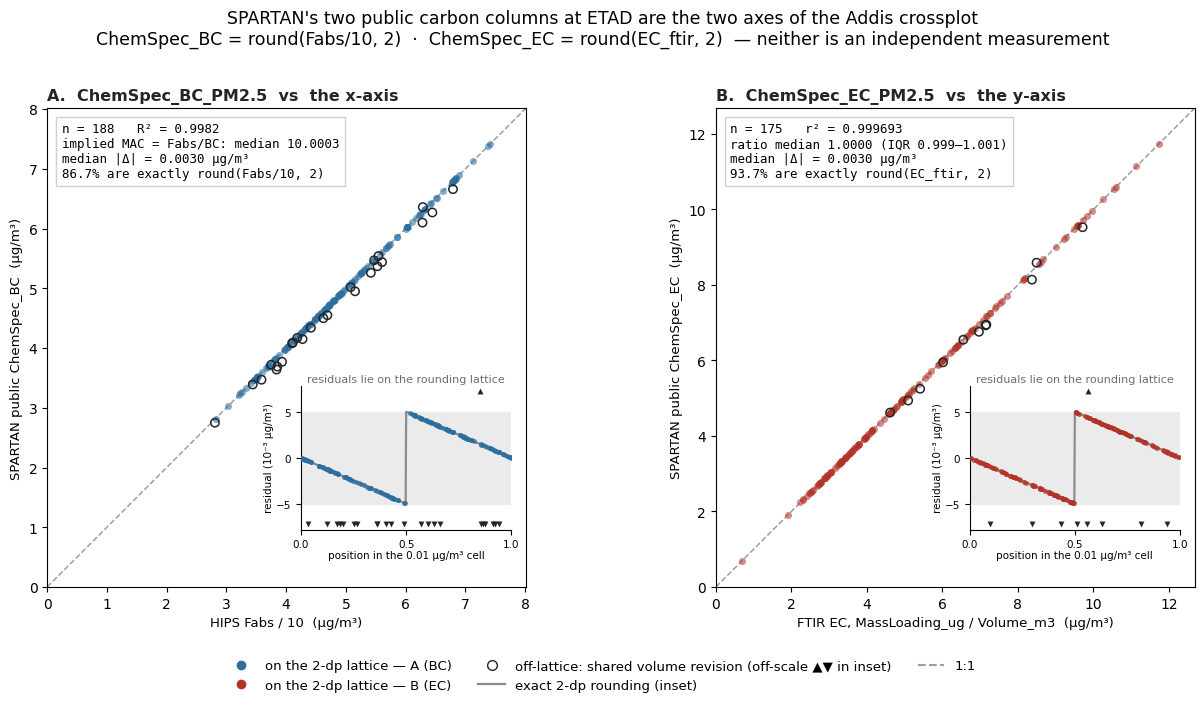

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 6.2))
PANELS = [
    dict(ax=axes[0], x=bc_pair['Fabs'] / 10, y=bc_pair['ChemSpec_BC'], on=bc_exact.to_numpy(),
         colour=BLUE, title='A.  ChemSpec_BC_PM2.5  vs  the x-axis',
         xlabel='HIPS Fabs / 10  (µg/m³)', ylabel='SPARTAN public ChemSpec_BC  (µg/m³)',
         note=(f'n = {bc_metrics["n"]}   R² = {bc_metrics["R2"]:.4f}\n'
               f'implied MAC = Fabs/BC: median {implied_mac_bc.median():.4f}\n'
               f'median |Δ| = {bc_resid.abs().median():.4f} µg/m³\n'
               f'{100 * bc_exact.mean():.1f}% are exactly round(Fabs/10, 2)')),
    dict(ax=axes[1], x=ec_pair['EC_ftir'], y=ec_pair['ChemSpec_EC'], on=ec_exact.to_numpy(),
         colour=ACCENT, title='B.  ChemSpec_EC_PM2.5  vs  the y-axis',
         xlabel='FTIR EC, MassLoading_ug / Volume_m3  (µg/m³)',
         ylabel='SPARTAN public ChemSpec_EC  (µg/m³)',
         note=(f'n = {ec_metrics["n"]}   r² = {ec_metrics["R2"]:.6f}\n'
               f'ratio median {ec_ratio.median():.4f} (IQR '
               f'{ec_ratio.quantile(.25):.3f}–{ec_ratio.quantile(.75):.3f})\n'
               f'median |Δ| = {ec_resid.abs().median():.4f} µg/m³\n'
               f'{100 * ec_exact.mean():.1f}% are exactly round(EC_ftir, 2)')),
]

for panel_spec in PANELS:
    ax, x, y, on = panel_spec['ax'], panel_spec['x'], panel_spec['y'], panel_spec['on']
    colour = panel_spec['colour']
    hi = float(max(x.max(), y.max())) * 1.08
    ax.plot([0, hi], [0, hi], '--', color='0.62', lw=1.1, zorder=1)
    ax.scatter(x[on], y[on], s=26, alpha=.55, color=colour, lw=0, zorder=3)
    ax.scatter(x[~on], y[~on], s=36, facecolors='none', edgecolors=INK, lw=1.1, zorder=4)
    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_aspect('equal')
    ax.set_title(panel_spec['title'], fontsize=11.5, color=INK, loc='left', fontweight='bold')
    ax.set_xlabel(panel_spec['xlabel'], fontsize=9.5)
    ax.set_ylabel(panel_spec['ylabel'], fontsize=9.5)
    ax.text(.03, .97, panel_spec['note'], transform=ax.transAxes, va='top', fontsize=9,
            fontfamily='monospace',
            bbox=dict(facecolor='white', edgecolor='0.8', alpha=.92))

    # Inset: residual vs position inside the 0.01 grid cell. Rounding => a triangle wave.
    inset = ax.inset_axes([.53, .12, .44, .30])
    cell = np.mod(np.asarray(x, float) * 100, 1.0)
    resid_milli = (np.asarray(y, float) - np.asarray(x, float)) * 1000
    grid = np.linspace(0, 1, 401)
    inset.plot(grid, np.where(grid < .5, -grid, 1 - grid) * 10, '-', color='0.55', lw=1.6,
               zorder=1, label='exact 2-dp rounding')
    inset.axhspan(-5, 5, color='0.92', zorder=0)
    inset.scatter(cell[on], resid_milli[on], s=13, color=colour, lw=0, alpha=.75, zorder=3)
    # Off-lattice residuals are 20–70× the rounding half-width; park them on the frame as
    # off-scale carets rather than rescaling the axis and flattening the lattice.
    for sign, marker in ((-1, 'v'), (1, '^')):
        stray = (np.sign(resid_milli[~on]) == sign) & (np.abs(resid_milli[~on]) > 7.0)
        inset.scatter(cell[~on][stray], np.full(int(stray.sum()), sign * 7.2), s=18,
                      color=INK, marker=marker, lw=0, zorder=4, clip_on=False)
    inset.set_ylim(-7.8, 7.8)
    inset.set_xlim(0, 1)
    inset.set_xticks([0, .5, 1])
    inset.set_yticks([-5, 0, 5])
    inset.tick_params(labelsize=7.5)
    inset.set_xlabel('position in the 0.01 µg/m³ cell', fontsize=7.5, labelpad=1)
    inset.set_ylabel('residual (10⁻³ µg/m³)', fontsize=7.5, labelpad=1)
    inset.set_title('residuals lie on the rounding lattice', fontsize=8, color=MUTED, pad=3)
    for spine in ('top', 'right'):
        inset.spines[spine].set_visible(False)

fig.legend(handles=[
    Line2D([], [], marker='o', ls='', color=BLUE, markersize=6,
           label='on the 2-dp lattice — A (BC)'),
    Line2D([], [], marker='o', ls='', color=ACCENT, markersize=6,
           label='on the 2-dp lattice — B (EC)'),
    Line2D([], [], marker='o', ls='', markerfacecolor='none', color=INK, markersize=7,
           label='off-lattice: shared volume revision (off-scale ▲▼ in inset)'),
    Line2D([], [], ls='-', color='0.55', lw=1.6, label='exact 2-dp rounding (inset)'),
    Line2D([], [], ls='--', color='0.62', label='1:1'),
], loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(.5, -.10), fontsize=9.5)
fig.suptitle('SPARTAN\'s two public carbon columns at ETAD are the two axes of the Addis '
             'crossplot\nChemSpec_BC = round(Fabs/10, 2)  ·  ChemSpec_EC = round(EC_ftir, 2)  '
             '— neither is an independent measurement', y=1.02, fontsize=12.5)
fig.tight_layout()
for target in (PLOT_DIR / 'chemspec_circularity_diagnostic.png',
               DECK_DIR / 'chemspec_circularity_diagnostic.png'):
    fig.savefig(target, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

### Part 3 — the consequence

State it plainly. `ChemSpec_BC` is circular with the **x**-axis (it is Fabs/10);
`ChemSpec_EC` is circular with the **y**-axis (it is FTIR EC). A crossplot of predicted EC
against Fabs/MAC therefore has no free variable left in the speciation table — **neither
column can arbitrate the intercept question**, and "not a Fabs transform" does not imply
independent. Independence is a claim about *both* axes and has to be checked against both.

In [13]:
verdict = pd.DataFrame([
    {'column': 'ChemSpec_BC_PM2.5', 'is': 'round(Fabs/10, 2)',
     'circular with': 'x-axis (HIPS Fabs)', 'n': int(bc_metrics['n']),
     'agreement': f'R² {bc_metrics["R2"]:.4f}; {100 * bc_exact.mean():.1f}% exact at 2 dp',
     'can arbitrate the intercept?': 'no'},
    {'column': 'ChemSpec_EC_PM2.5', 'is': 'round(EC_ftir, 2)',
     'circular with': 'y-axis (FTIR EC product)', 'n': int(ec_metrics['n']),
     'agreement': f'r² {ec_metrics["R2"]:.6f}; {100 * ec_exact.mean():.1f}% exact at 2 dp',
     'can arbitrate the intercept?': 'no'},
])
display(verdict)
verdict.to_csv(TABLE_DIR / 'circularity_verdict.csv', index=False)

print('DEAD: the Addis curvature test as planned. It fits Fabs against an independent EC and '
      'asks whether a power law beats a straight line — the diagnostic that would separate '
      '"the intercept is a real non-EC absorption offset" from "the Fabs–EC relation is '
      'simply curved". It needs an EC reference circular with NEITHER axis. In the committed '
      'data no such reference exists: ChemSpec_EC is the y-axis, ChemSpec_BC is the x-axis, '
      'and there is no third carbon column.')
print('CONSEQUENCE: quartz-filter TOR is promoted from one option among several to the '
      'decisive measurement — it is the only EC reference that is neither the HIPS number '
      'nor the FTIR product. The ftir_16 campaign spec (~12 days × 3 seasons of co-located '
      'quartz, IMPROVE_A TOR) is now on the critical path rather than a nice-to-have.')

,column,is,circular with,n,agreement,can arbitrate the intercept?
0,ChemSpec_BC_PM2.5,"round(Fabs/10, 2)",x-axis (HIPS Fabs),188,R² 0.9982; 86.7% exact at 2 dp,no
1,ChemSpec_EC_PM2.5,"round(EC_ftir, 2)",y-axis (FTIR EC product),175,r² 0.999693; 93.7% exact at 2 dp,no


DEAD: the Addis curvature test as planned. It fits Fabs against an independent EC and asks whether a power law beats a straight line — the diagnostic that would separate "the intercept is a real non-EC absorption offset" from "the Fabs–EC relation is simply curved". It needs an EC reference circular with NEITHER axis. In the committed data no such reference exists: ChemSpec_EC is the y-axis, ChemSpec_BC is the x-axis, and there is no third carbon column.
CONSEQUENCE: quartz-filter TOR is promoted from one option among several to the decisive measurement — it is the only EC reference that is neither the HIPS number nor the FTIR product. The ftir_16 campaign spec (~12 days × 3 seasons of co-located quartz, IMPROVE_A TOR) is now on the critical path rather than a nice-to-have.


#### What the speciation table is still good for

The circularity is specific to the two carbon columns. The **elemental** columns are XRF
measurements with no FTIR or HIPS input, and they are complete over the same 188 ETAD
filters. There is no `RCFM` or dust column in the committed dataset, so a dust term has to
be **constructed** — IMPROVE soil is the standard route.

In [14]:
ELEMENTS = ['Aluminum', 'Silicon', 'Calcium', 'Iron', 'Titanium', 'Magnesium']
element_panel = pd.concat({el: measurement(f'ChemSpec_{el}_PM2.5') for el in ELEMENTS}, axis=1)
display(pd.DataFrame({
    'filters': element_panel.notna().sum(),
    'median (ng/m³)': element_panel.median().round(1),
    'IQR lo': element_panel.quantile(.25).round(1),
    'IQR hi': element_panel.quantile(.75).round(1),
    'values < 0 (below MDL)': (element_panel < 0).sum(),
}))
assert (element_panel.notna().sum() == 188).all()
assert not [p for p in raw['Parameter'].unique()
            if any(k in p.lower() for k in ('rcfm', 'dust', 'soil'))], 'a dust column exists'
print('no RCFM / dust / soil parameter anywhere in the unified dataset — the proxy must be built')

# IMPROVE soil (Malm et al. 1994), ng/m³ -> µg/m³.
soil = (2.20 * element_panel['Aluminum'] + 2.49 * element_panel['Silicon']
        + 1.63 * element_panel['Calcium'] + 2.42 * element_panel['Iron']
        + 1.94 * element_panel['Titanium']) / 1000.0
pm25 = measurement('ChemSpec_Filter_PM2.5_mass')
soil_frac = (soil / pm25).dropna()
print(f'constructed IMPROVE-soil proxy: n = {int(soil.notna().sum())} ETAD filters, '
      f'median {soil.median():.2f} µg/m³ (IQR {soil.quantile(.25):.2f}–{soil.quantile(.75):.2f}), '
      f'{100 * soil_frac.median():.1f}% of ChemSpec PM2.5 mass at the median')
print('Mg is available on the same 188 filters but is not in the IMPROVE soil formula; it '
      'carries the noisiest below-MDL tail of the six, so any SPARTAN-style dust variant '
      'that uses it should be reported alongside the IMPROVE form, not instead of it.')
pd.concat({'soil_ugm3': soil, 'PM25_ugm3': pm25}, axis=1).to_csv(TABLE_DIR / 'etad_improve_soil_proxy.csv')

,filters,median (ng/m³),IQR lo,IQR hi,values < 0 (below MDL)
Aluminum,188,350.4,264.9,509.9,0
Silicon,188,1193.9,899.7,1601.7,0
Calcium,188,315.2,236.5,434.1,0
Iron,188,290.5,219.8,409.0,0
Titanium,188,25.5,19.7,38.0,0
Magnesium,188,163.5,92.9,257.1,20


no RCFM / dust / soil parameter anywhere in the unified dataset — the proxy must be built
constructed IMPROVE-soil proxy: n = 188 ETAD filters, median 4.98 µg/m³ (IQR 3.84–6.78), 24.5% of ChemSpec PM2.5 mass at the median
Mg is available on the same 188 filters but is not in the IMPROVE soil formula; it carries the noisiest below-MDL tail of the six, so any SPARTAN-style dust variant that uses it should be reported alongside the IMPROVE form, not instead of it.


## Takeaways

- **Neither ChemSpec carbon column is admissible evidence about the intercept.** `ChemSpec_BC`
  is circular with the x-axis (it is `round(Fabs/10, 2)`), `ChemSpec_EC` is circular with the
  y-axis (it is `round(EC_ftir, 2)`). A crossplot of predicted EC against Fabs/MAC has no free
  variable left in SPARTAN's public speciation table.
- **Correct the ftir_16 record.** Its conclusion "`ChemSpec_EC` is HIPS Fabs/10" reached the
  right action for the wrong reason: the column is not a Fabs transform, it is the FTIR
  product. The distinction matters because the wrong reason implies a ChemSpec column that
  *isn't* Fabs would be usable — the opposite of the truth here. Its implied MAC of 9.89 is
  simply FTIR EC's own implied MAC, and carries no information about the MAC fork.
- **The R² match was the tell, and it was read backwards.** Two quantities that are the same
  product must have the same relationship to any third quantity, so `ChemSpec_EC` scoring
  0.7904 against Fabs/10 where `EC_ftir` scores 0.7908 is proof of identity, not of
  independence. Any future "independent reference" claim should be tested against **both**
  axes and against the 2-dp lattice, not just against the x-axis.
- **The Addis curvature test is dead as designed.** Distinguishing "the intercept is real
  non-EC absorption" from "the Fabs–EC relation is curved" requires an EC reference circular
  with neither axis. The committed data contains none. This is what promotes the ftir_16
  quartz-TOR campaign (~12 days × 3 seasons, IMPROVE_A) from one option among several onto the
  critical path.
- **Join hygiene is part of the result, not preamble.** Both traps fail silently and both
  produce plausible numbers: the committed base-id regex empties every ChemSpec join, and
  averaging the duplicated ChemSpec rows manufactures an implied MAC of 19.57 m²/g — a number
  physical enough to build a story on. Use the measurement row, and strip the replicate suffix
  with a fall-back to the id as it stands.
- **What survives**: the elemental columns are XRF and share no input with FTIR or HIPS. They
  cover all 188 ETAD filters, and since the dataset has no RCFM or dust parameter, a dust term
  must be constructed — IMPROVE soil is the standard route (Mg is available on the same
  filters but sits outside that formula and carries the noisiest below-MDL tail, 20 of 188
  negative).
- **Caveats**: 25 of 188 BC filters and 11 of 175 EC filters sit off the 2-dp lattice; the 9
  that miss in both are explained by a shared post-snapshot volume revision, the remainder are
  BC-only filters with no ChemSpec EC partner and are not diagnosed here. The four-site pooled
  r² computed on this pickle is 0.999544 against the 0.99992 quoted in `docs/open-items.md`
  (different join/subset, same phenomenon). The SPARTAN cross-site corroboration is read from
  a committed table (n = 232 at ETAD, a wider public-BC pull than the 188 filters audited
  here), not re-derived.